### Large Juneau Domain - Sites Map Figure for the Deliverable 

created by Cassie Lumbrazo\
last updated: May 2026\
run location: UAS linux\
python environment: **rasterio**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

import rioxarray
import rasterio 
import cfgrib
import os

import geopandas as gpd
from shapely.geometry import Point

In [2]:
import xarray as xr
import geopandas as gpd
from shapely.geometry import Point
import rioxarray  # For CRS handling

In [3]:
pwd

'/home/cassie/python/repos/snow_modeling_point/large_juneau_domain'

## Load HRRR-AK UTM NetCDF

In [4]:
# Path to the NetCDF file
utm_output_path = "/hdd/snow_hydrology/hrrrak/large_juneau_domain/netcdf/hrrrak_merged_grib_f567_WY2025_utm.nc"

# Open the NetCDF dataset
ds_utm = xr.open_dataset(utm_output_path)

# Check the CRS (it might be None if not properly embedded)
print(f"Loaded CRS: {ds_utm.rio.crs}")

# If CRS is None, assign it manually (since it was reprojected to EPSG:32608)
if ds_utm.rio.crs is None:
    ds_utm.rio.write_crs("EPSG:32608", inplace=True)
    print("Assigned CRS: EPSG:32608")

# Now the dataset has the CRS set
print(f"Final CRS: {ds_utm.rio.crs}")

Loaded CRS: None
Assigned CRS: EPSG:32608
Final CRS: EPSG:32608


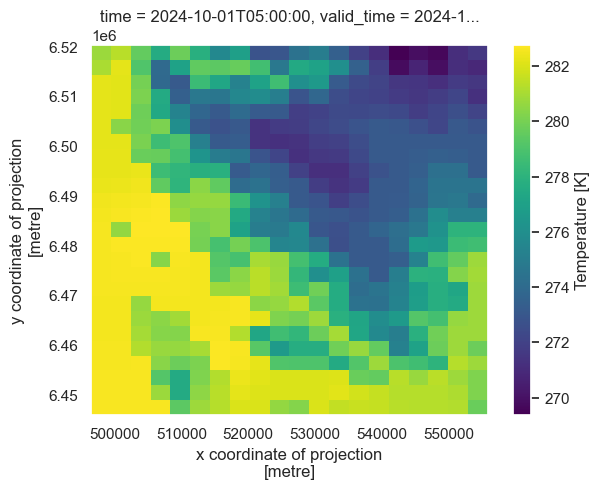

In [5]:
ds_utm.temp_surface[0].plot()

So that looks great, now the crs is actually set, reporjected to utm, and the data can be easily used. 

# Plot the Sites

### First, as a map

In [6]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

Text(0.5, 1.0, 'HRRR temp (single timestep) with site locations')

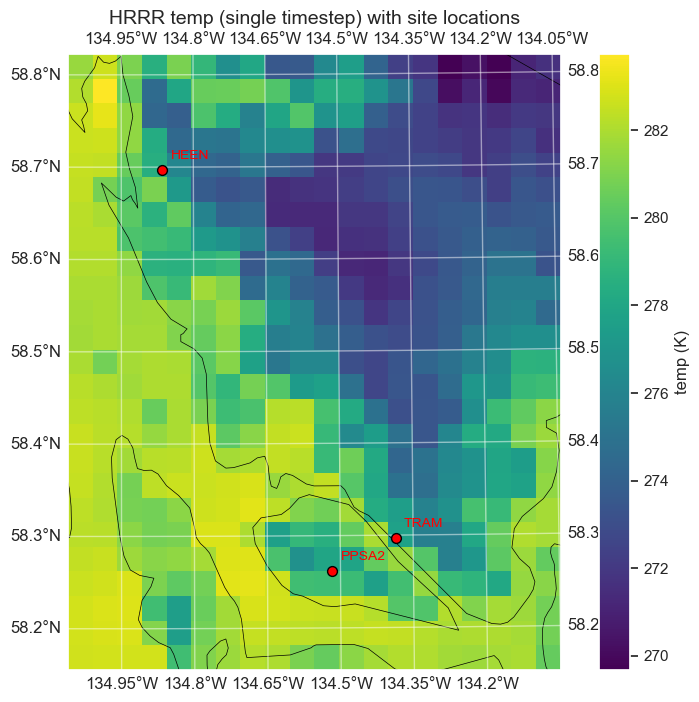

In [7]:
# Site coordinates (lat/lon, WGS84)
sites = {
    "ppsa2": {"lat": 58.26200, "lon": -134.51700},
    "tram": {"lat": 58.2971, "lon": -134.386},
    "heen": {"lat": 58.69652, "lon": -134.86448},
    # "tkg4": {"lat": 58.63447, "lon": -134.237}
}

# Create GeoDataFrame for sites
gdf_sites = gpd.GeoDataFrame({
    "site": list(sites.keys()),
    "geometry": [Point(sites[site]["lon"], sites[site]["lat"]) for site in sites]
}, crs="EPSG:4326")

# Convert sites to UTM (same as dataset)
gdf_sites_utm = gdf_sites.to_crs("EPSG:32608")

# Select a variable for background (e.g., temp at first time step)
var_name = 'temp'  # Change to any variable, e.g., 'temp', 'precip_total'
background_data = ds_utm[var_name].isel(time=0)  # First time step

# Plot setup
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.UTM(8)})  # UTM Zone 8N

# Plot the background raster
background_data.plot(ax=ax, cmap='viridis', add_colorbar=True, cbar_kwargs={'label': f'{var_name} ({background_data.attrs.get("units", "")})'})

# Add coastlines and features for context
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.gridlines(draw_labels=True, alpha=0.5)

# Plot site points
for idx, row in gdf_sites_utm.iterrows():
    x, y = row.geometry.x, row.geometry.y
    ax.scatter(x, y, color='red', s=50, edgecolor='black', zorder=5)
    ax.text(x + 1000, y + 1000, row['site'].upper(), fontsize=10, color='red', ha='left', va='bottom', zorder=6)

# Set title
ax.set_title(f"HRRR {var_name} (single timestep) with site locations", fontsize=14)

# # Save or show the plot
# plt.tight_layout()
# plt.savefig("/hdd/snow_hydrology/hrrrak/large_juneau_domain/plots/hrrr_temp_sites_map.png", dpi=300)
# plt.show()

# print("✅ Map plotted and saved!")

In [8]:
# lat_ppsa2, lon_ppsa2, elevation_ppsa2 = 58.26200, -134.51700, 670
# lat_tram, lon_tram, elevation_tram = 58.2971, -134.386, 529
# lat_heen, lon_heen, elevation_heen = 58.69652, -134.86448, 548
# lat_tkg4, lon_tkg4, elevation_tkg4 = 58.63447,-134.23708, 1120

In [9]:
ds_utm.orog

<xarray.DataArray 'orog' (time: 8760, y: 25, x: 20)> Size: 35MB
[4380000 values with dtype=float64]
Coordinates:
  * time         (time) datetime64[ns] 70kB 2024-10-01T05:00:00 ... 2025-10-0...
    valid_time   (time) datetime64[ns] 70kB ...
    step         (time) timedelta64[ns] 70kB ...
  * y            (y) float64 200B 6.519e+06 6.516e+06 ... 6.45e+06 6.447e+06
  * x            (x) float64 160B 4.98e+05 5.009e+05 ... 5.514e+05 5.544e+05
    spatial_ref  int64 8B 0
Attributes:
    long_name:       Orography
    units:           m
    GRIB_shortName:  orog
    GRIB_name:       Orography
    GRIB_cfName:     geopotential_height
    GRIB_cfVarName:  orog
    level:           0
    typeOfLevel:     surface

In [10]:
# File paths 
filepath = '/hdd/snow_hydrology/DEMs/ArcticDEM_edits/large_juneau_domain/'
filename =  'dem_2m_UTM_clip_large_juneau_domain.tif'# now, this file should be in UTM coordinates (EPSG:32608)
raster_path = os.path.join(filepath, filename)

# open the DEM with rioxarray
dem = rioxarray.open_rasterio(raster_path, masked=True)
dem = dem.rio.write_crs("EPSG:32608")  # Set the CRS to UTM Zone 8N

dem.rio.crs

CRS.from_wkt('PROJCS["WGS 84 / UTM zone 8N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-135],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32608"]]')

In [11]:
dem

<xarray.DataArray (band: 1, y: 36622, x: 30170)> Size: 4GB
[1104885740 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 241kB 4.957e+05 4.957e+05 ... 5.56e+05 5.56e+05
  * y            (y) float64 293kB 6.519e+06 6.519e+06 ... 6.446e+06 6.446e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

# Trying New Code here 

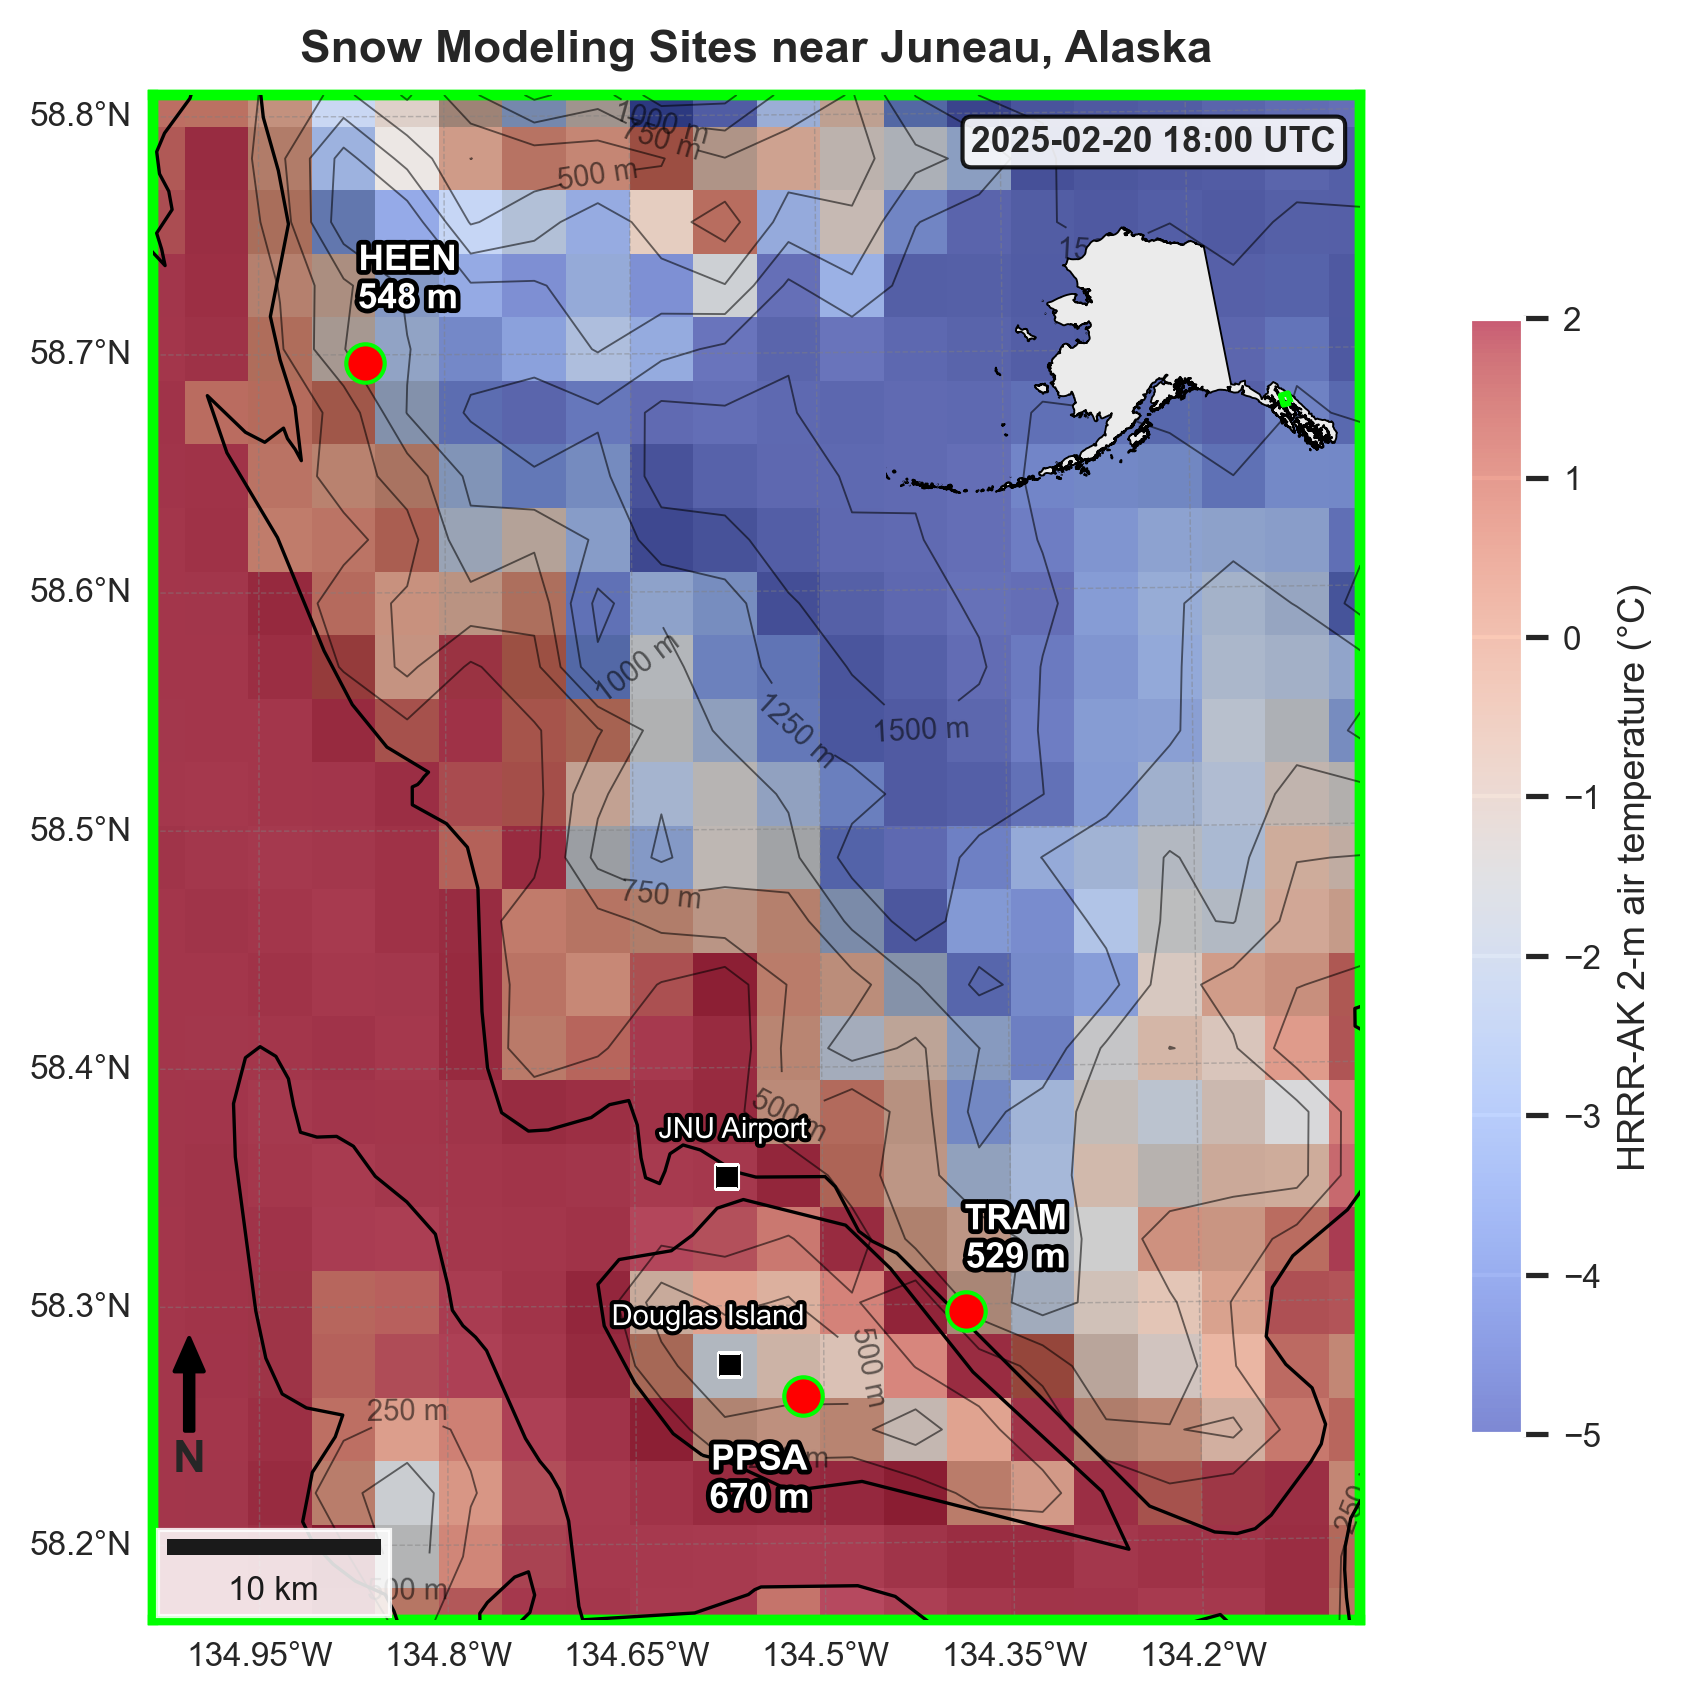

In [57]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import LightSource
from matplotlib_scalebar.scalebar import ScaleBar
from shapely.geometry import Point, box

import cartopy.crs as ccrs
import cartopy.feature as cfeature


# =============================================================================
# USER SETTINGS
# =============================================================================

plot_time = pd.to_datetime("2025-02-20T18:00:00")

show_temperature = True      # True = overlay HRRR-AK TA; False = topo-only map
temp_min = -5
temp_max = 2

alaska_shp = '/hdd/snow_hydrology/shape_files/alaska_censusdotgov.shp'   # dropped it in here for now 

site_marker_size = 85
fontsize = 9

proj = ccrs.UTM(8)
pc = ccrs.PlateCarree()


# =============================================================================
# SITE INFORMATION
# =============================================================================

sites = {
    "PPSA": {"lat": 58.26200, "lon": -134.51700, "elev": 670},
    "TRAM": {"lat": 58.29710, "lon": -134.38600, "elev": 529},
    "HEEN": {"lat": 58.69652, "lon": -134.86448, "elev": 548},
}

gdf_sites = gpd.GeoDataFrame(
    {
        "site_id": list(sites.keys()),
        "elev_m": [sites[s]["elev"] for s in sites],
        "geometry": [Point(sites[s]["lon"], sites[s]["lat"]) for s in sites],
    },
    crs="EPSG:4326",
)


# =============================================================================
# DATA PREP
# =============================================================================

terrain = ds_utm["orog"].isel(time=0)

x = ds_utm["x"].values
y = ds_utm["y"].values
z = terrain.values

# Hillshade from HRRR-AK orography
ls = LightSource(azdeg=315, altdeg=45)
hillshade = ls.hillshade(
    z,
    vert_exag=1.5,
    dx=np.nanmedian(np.diff(x)),
    dy=np.nanmedian(np.diff(y)),
)

if show_temperature:
    temp = ds_utm["temp"].sel(time=plot_time, method="nearest") - 273.15
    actual_time = pd.to_datetime(temp["time"].values)
else:
    actual_time = None


# Domain in UTM
xmin, xmax = np.nanmin(x), np.nanmax(x)
ymin, ymax = np.nanmin(y), np.nanmax(y)

domain_poly_utm = gpd.GeoDataFrame(
    geometry=[box(xmin, ymin, xmax, ymax)],
    crs="EPSG:32608",
).to_crs("EPSG:4326")

# =============================================================================
# FIGURE SETUP
# =============================================================================

fig = plt.figure(figsize=(7.2, 6.2), dpi=300)

ax = fig.add_axes([0.08, 0.10, 0.72, 0.82], projection=proj) 

# Move Alaska inset to upper-right instead of upper-left
ax_inset = fig.add_axes(
    [0.5, 0.66, 0.23, 0.23], # left, bottom, width, height
    projection=ccrs.AlbersEqualArea(
        central_longitude=-154,
        central_latitude=50,
        standard_parallels=(55, 65),
    )
)

# Move colorbar closer to main map
# cax = fig.add_axes([0.805, 0.20, 0.025, 0.60])
cax = fig.add_axes([0.77, 0.20, 0.025, 0.60]) # trying to move it closer 


# =============================================================================
# MAIN MAP: HILLSHADE + OPTIONAL TEMPERATURE
# =============================================================================

ax.pcolormesh(
    x, y, hillshade,
    cmap="Greys",
    shading="auto",
    transform=proj,
    alpha=0.95,
    zorder=1,
)

if show_temperature:
    im = ax.pcolormesh(
        x, y, temp.values,
        cmap="coolwarm",
        shading="auto",
        vmin=temp_min,
        vmax=temp_max,
        transform=proj,
        alpha=0.62,
        zorder=2,
    )

    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("HRRR-AK 2-m air temperature (°C)", fontsize=fontsize)
    cbar.ax.tick_params(labelsize=fontsize - 1)
else:
    cax.set_visible(False)


# =============================================================================
# TOPOGRAPHY CONTOURS
# =============================================================================

contours = ax.contour(
    x, y, z,
    levels=[250, 500, 750, 1000, 1250, 1500],
    colors="black",
    linewidths=0.45,
    alpha=0.55,
    transform=proj,
    zorder=3,
)

ax.clabel(
    contours,
    inline=True,
    fontsize=7,
    fmt="%d m",
)


# =============================================================================
# MAP FEATURES
# =============================================================================

ax.set_extent([xmin, xmax, ymin, ymax], crs=proj)

ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=4)
ax.add_feature(cfeature.LAKES, linewidth=0.4, alpha=0.4, zorder=4)
ax.add_feature(cfeature.RIVERS, linewidth=0.3, alpha=0.35, zorder=4)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.35,
    color="gray",
    alpha=0.45,
    linestyle="--",
)

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 8}
gl.ylabel_style = {"size": 8}


# =============================================================================
# SITE MARKERS
# =============================================================================

label_offsets = {
    "PPSA": (-0.035, -0.035),
    "TRAM": (0.040, 0.030),   # shifted up
    "HEEN": (0.035, 0.035),   # shifted up
}

for _, row in gdf_sites.iterrows():
    lon = row.geometry.x
    lat = row.geometry.y
    site = row["site_id"]

    ax.scatter(
        lon, lat,
        s=site_marker_size,
        marker="o",
        facecolor="red",
        # edgecolor="black",
        edgecolor="lime",
        linewidth=1.0,
        transform=pc,
        zorder=10,
    )

    dx, dy = label_offsets.get(site, (0.02, 0.02))

    txt = ax.text(
        lon + dx,
        lat + dy,
        f"{site}\n{int(row['elev_m'])} m",
        fontsize=8.5,
        fontweight="bold",
        ha="center",
        va="center",
        color="white",
        transform=pc,
        zorder=11,
    )

    txt.set_path_effects([
        pe.withStroke(linewidth=2.3, foreground="black")
    ])


# =============================================================================
# LANDMARKS
# =============================================================================

landmarks = [
    {
        "name": "JNU Airport",
        "lon": -134.576,
        "lat": 58.354,
        "marker": "s",
        "dx": -0.055,     # shift label right
        "dy": 0.02,
        "ha": "left",
    },
    {
        "name": "Douglas Island",
        "lon": -134.575,
        "lat": 58.275,
        "marker": "s",
        "dx": 0.06,
        "dy": 0.02,
        "ha": "right",
    },
]

for lm in landmarks:
    ax.scatter(
        lm["lon"], lm["lat"],
        transform=pc,
        s=35,
        marker=lm["marker"],
        facecolor="black",
        edgecolor="white",
        linewidth=0.5,
        zorder=9,
    )

    txt = ax.text(
        lm["lon"] + lm["dx"],
        lm["lat"] + lm["dy"],
        lm["name"],
        fontsize=7,
        color="white",
        ha=lm["ha"],
        va="center",
        transform=pc,
        zorder=10,
    )

    txt.set_path_effects([
        pe.withStroke(linewidth=2.0, foreground="black")
    ])


# =============================================================================
# SCALE BAR + NORTH ARROW
# =============================================================================

scalebar = ScaleBar(
    dx=1,
    units="m",
    location="lower left",
    length_fraction=0.22,
    box_alpha=0.85,
    font_properties={"size": 8},
)

ax.add_artist(scalebar)

ax.annotate(
    "N",
    xy=(0.03, 0.185),      # arrow head, change the first number to move it left/right
    xytext=(0.03, 0.105),  # N label / arrow tail
    xycoords=ax.transAxes,
    ha="center",
    va="center",
    fontsize=11,
    fontweight="bold",
    arrowprops=dict(
        facecolor="black",
        edgecolor="black",
        width=2,
        headwidth=7,
        headlength=8,
    ),
    zorder=20,
)


# =============================================================================
# TIMESTAMP
# =============================================================================

if show_temperature:
    timestamp_str = actual_time.strftime("%Y-%m-%d %H:%M UTC")

    ax.text(
        0.98, 0.98,
        timestamp_str,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8.5,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            alpha=0.88,
            boxstyle="round,pad=0.25",
        ),
        zorder=20,
    )


# =============================================================================
# ALASKA INSET
# =============================================================================

ak = gpd.read_file(alaska_shp).to_crs(ax_inset.projection.proj4_init)

ak.plot(
    ax=ax_inset,
    facecolor="0.92",
    edgecolor="black",
    linewidth=0.45,
    zorder=1,
)

domain_poly_ak = domain_poly_utm.to_crs(ax_inset.projection.proj4_init)
domain_poly_ak.boundary.plot(
    ax=ax_inset,
    edgecolor="lime",
    linewidth=1.4,
    zorder=5,
)

ax_inset.set_extent([-180, -128, 50, 73], crs=pc)
ax_inset.set_axis_off()

# ax_inset.text(
#     -0.5, 0.8,
#     "Alaska",
#     transform=ax_inset.transAxes,
#     ha="left",
#     va="top",
#     fontsize=8,
#     fontweight="bold",
# )

# =============================================================================
# LIME GREEN FRAME AROUND MAP
# =============================================================================

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor("lime")
    spine.set_linewidth(2.5)


# =============================================================================
# TITLE / EXPORT
# =============================================================================

ax.set_title(
    "Snow Modeling Sites near Juneau, Alaska",
    fontsize=11,
    fontweight="bold",
    pad=8,
)

# plt.savefig(
#     "figure_site_map_juneau_topography_temperature.pdf",
#     dpi=300,
#     bbox_inches="tight",
# )

# plt.savefig(
#     "figure_site_map_juneau_topography_temperature.png",
#     dpi=300,
#     bbox_inches="tight",
# )

plt.show()